# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [88]:
import math

import numpy as np
import pandas as pd
import re

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm


In [89]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8')

In [90]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [91]:
df_reviews = pd.read_csv('../data/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [92]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [93]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  str    
 1   title_type       47331 non-null  str    
 2   primary_title    47331 non-null  str    
 3   original_title   47331 non-null  str    
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  str    
 6   runtime_minutes  47331 non-null  str    
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  str    
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  str    
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  str    
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  str    
 16  idx              47331 non-null  int64  
dtypes: Int64(1), float64(1)

In [94]:
df_reviews.describe()

,start_year,is_adult,average_rating,votes,rating,pos,idx
count,47331.000000,47331.000000,47329.000000,47329.0,47331.000000,47331.000000,47331.000000
mean,1989.631235,0.001732,5.998278,25562.917323,5.484608,0.498954,6279.697999
std,19.600364,0.041587,1.494289,83670.039163,3.473109,0.500004,3605.702545
min,1894.000000,0.000000,1.400000,9.0,1.000000,0.000000,0.000000
25%,1982.000000,0.000000,5.100000,827.0,2.000000,0.000000,3162.000000
50%,1998.000000,0.000000,6.300000,3197.0,4.000000,0.000000,6299.000000
75%,2004.000000,0.000000,7.100000,13974.0,9.000000,1.000000,9412.000000
max,2010.000000,1.000000,9.700000,1739448.0,10.000000,1.000000,12499.000000


## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

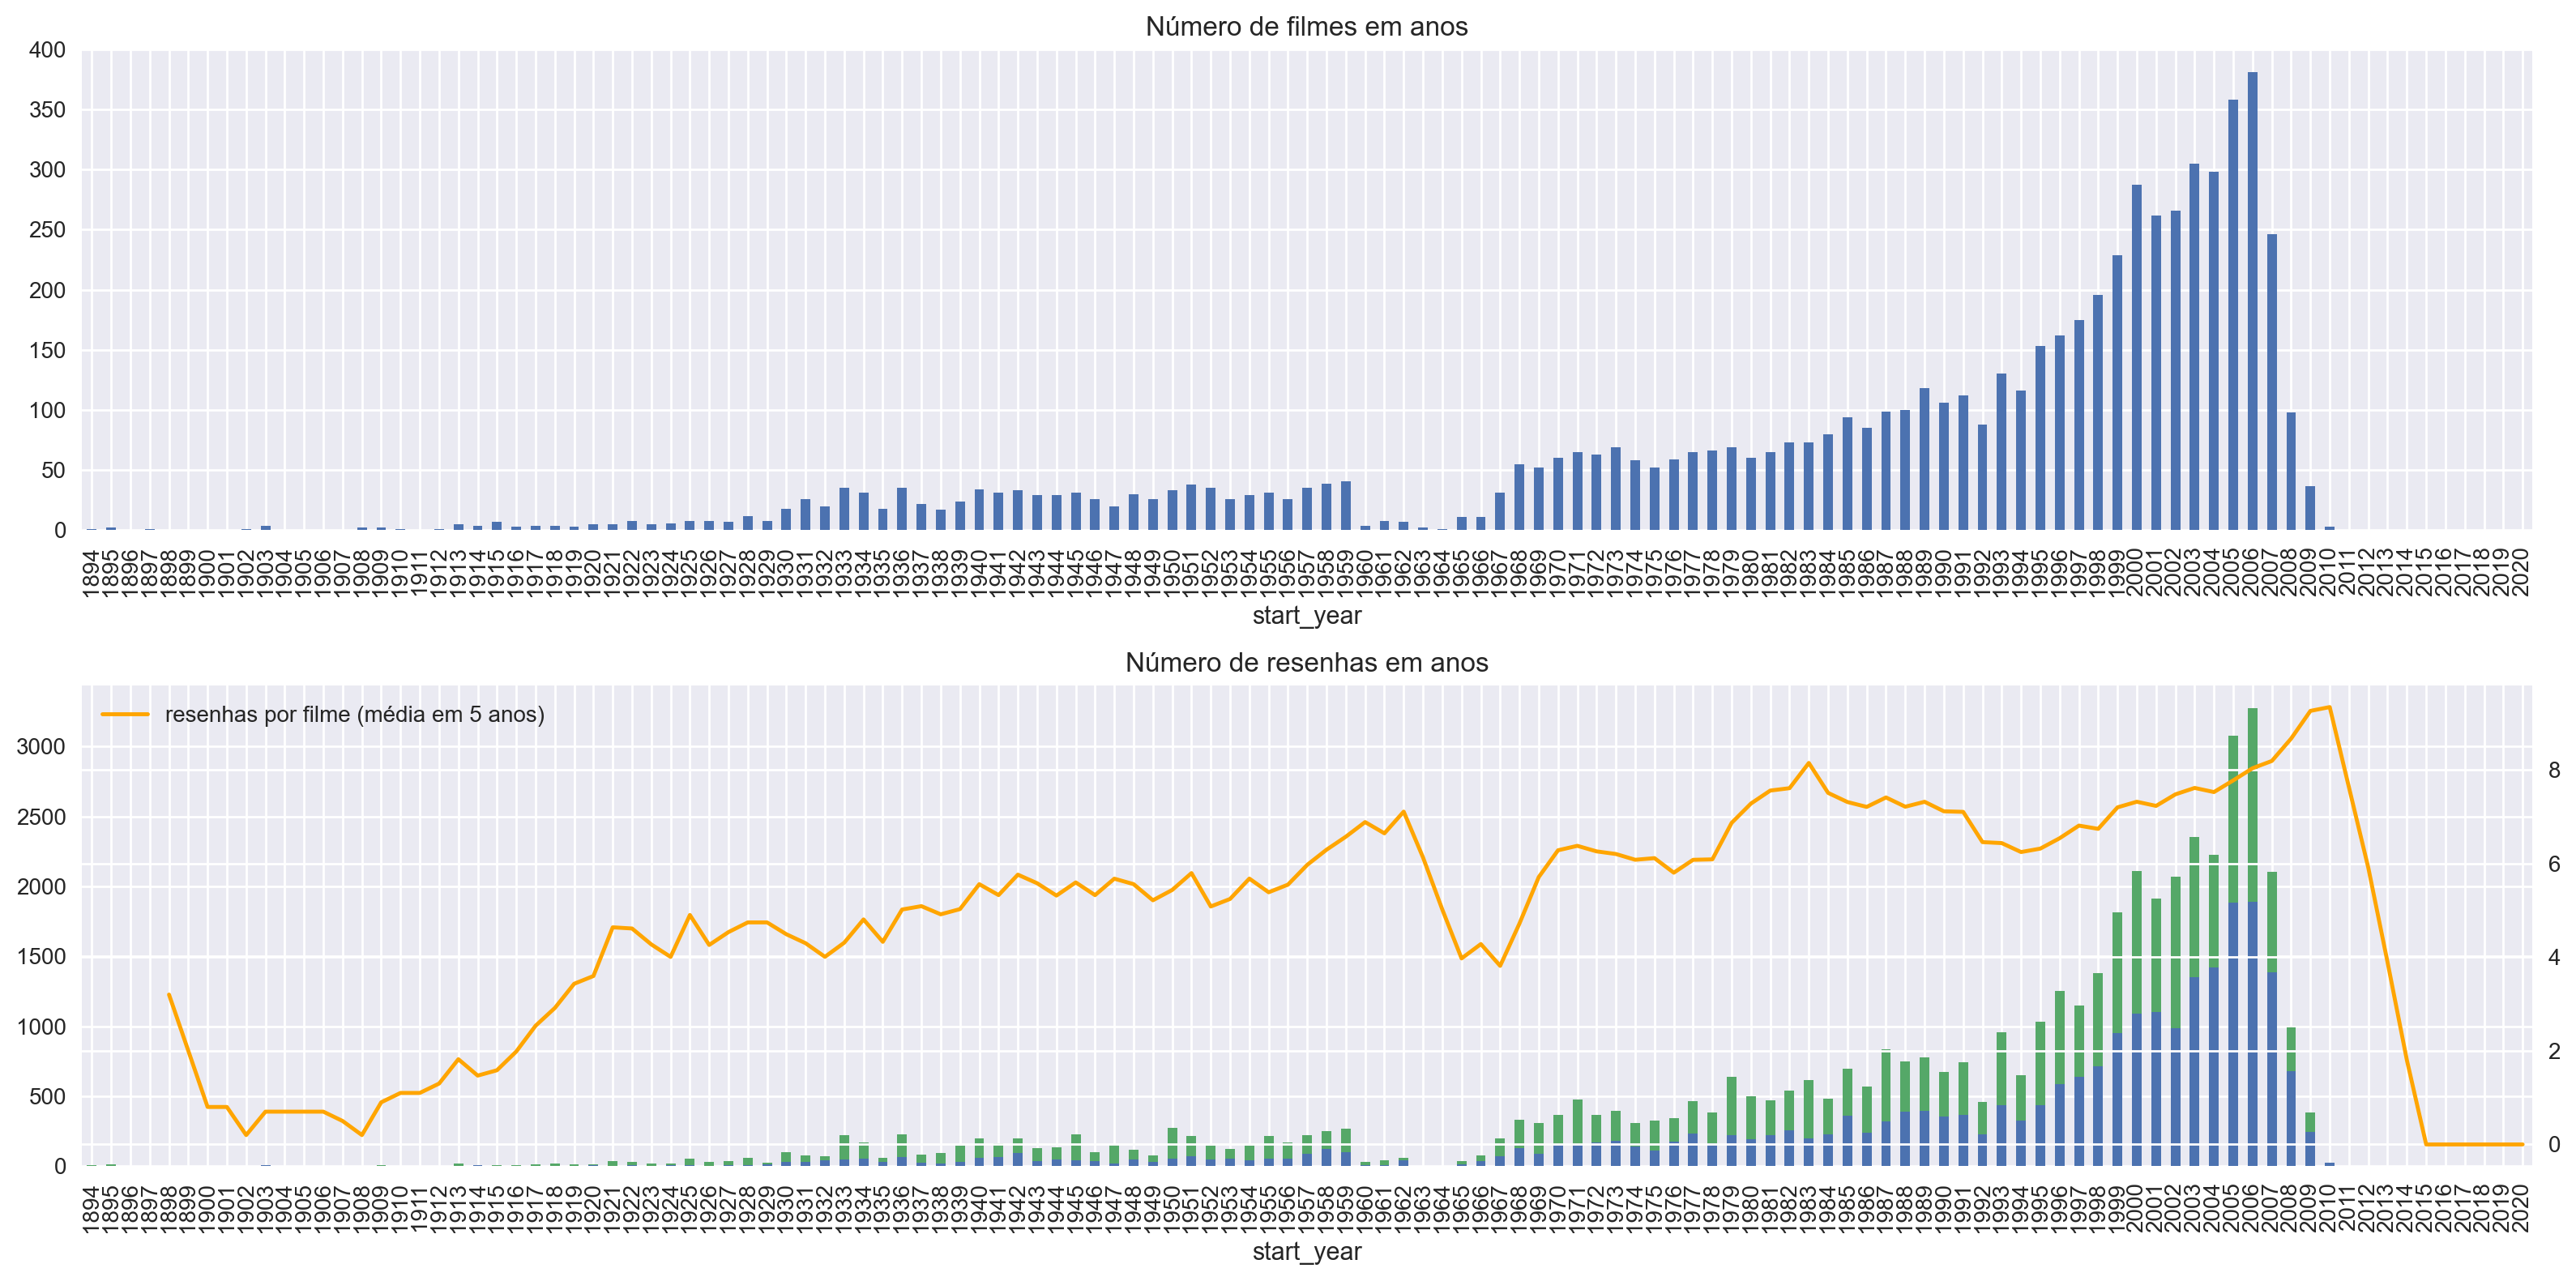

In [95]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

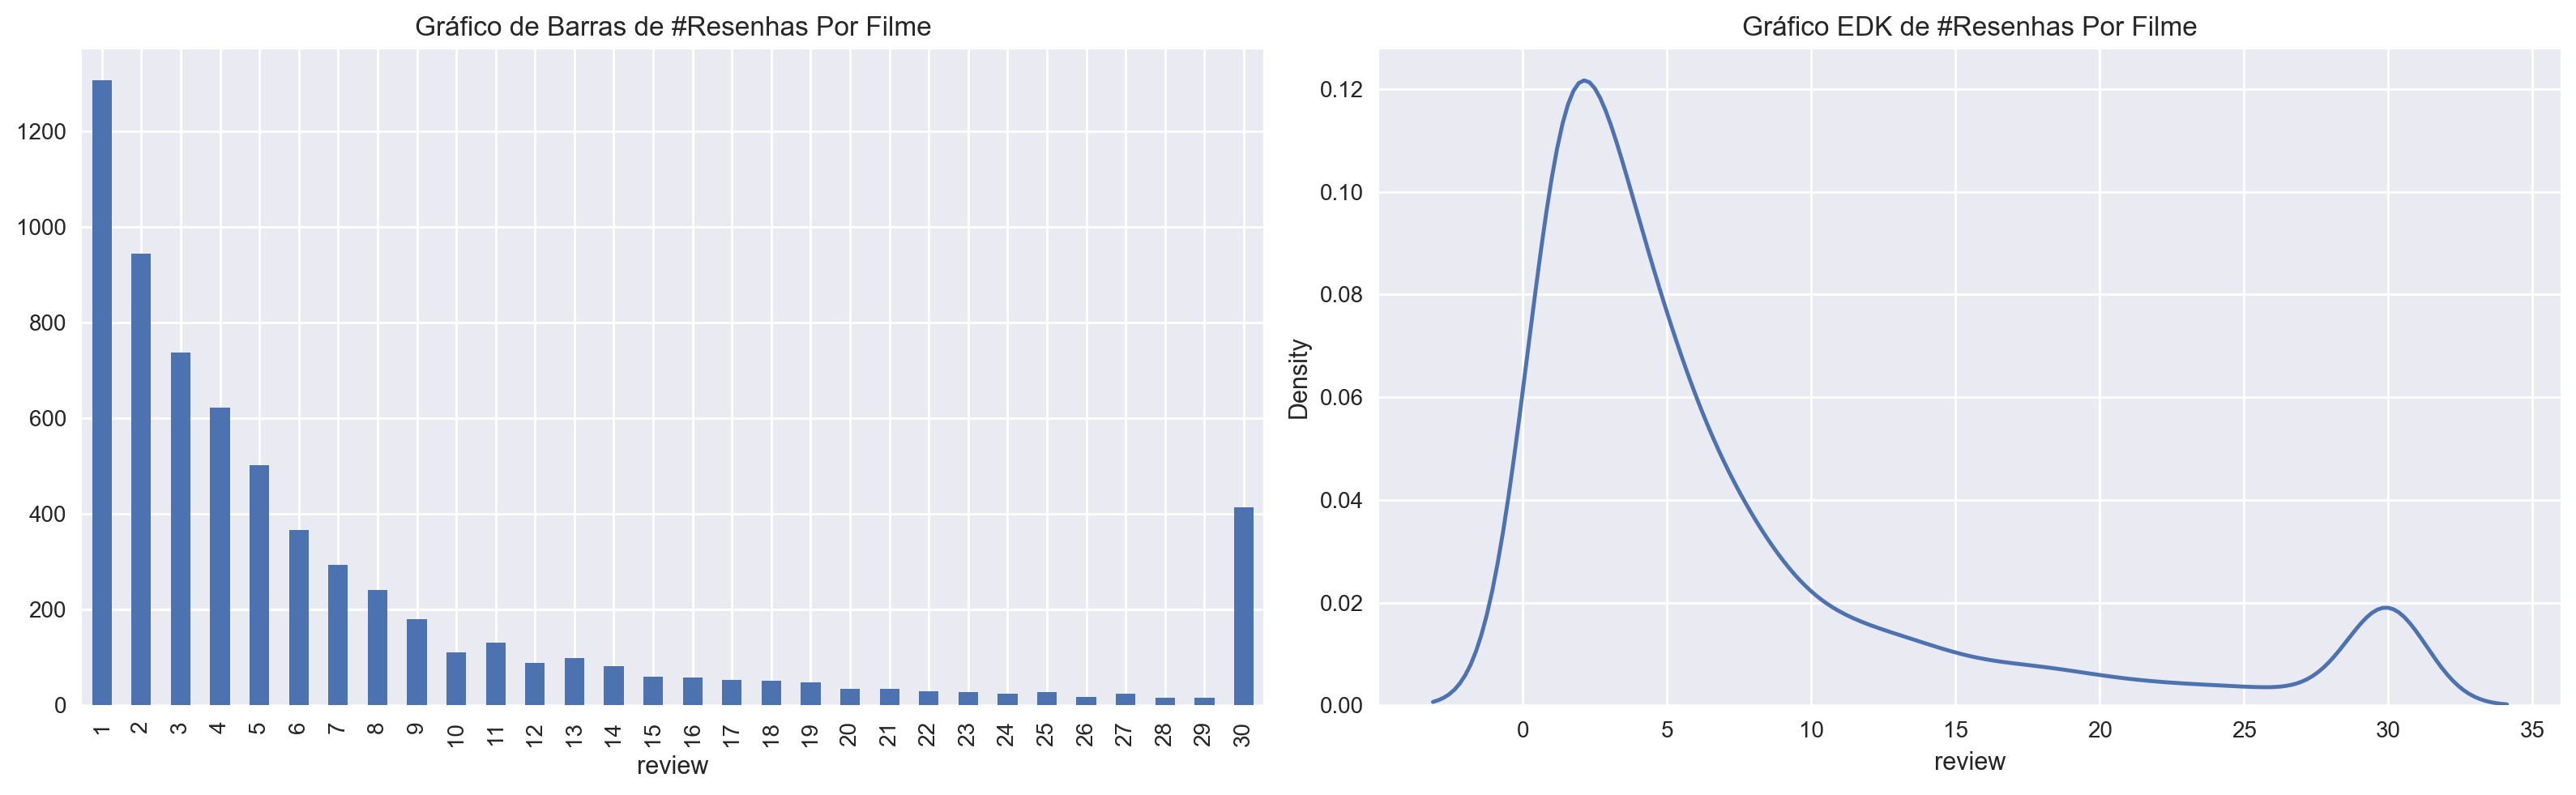

In [96]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

In [97]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

<div class="alert alert-block alert-warning">
  <strong>Comentário:</strong> <a class="tocSkip"></a><br><br>
  Excelente trabalho na análise da distribuição das variáveis!  
  Se quiser verificar as porcentagens em vez dos valores absolutos, basta utilizar o argumento <code>normalize=True</code> com o método <code>value_counts()</code>.  
  <br><br>Exemplo:
  <pre><code>df['sua_coluna'].value_counts(normalize=True)</code></pre>
</div>


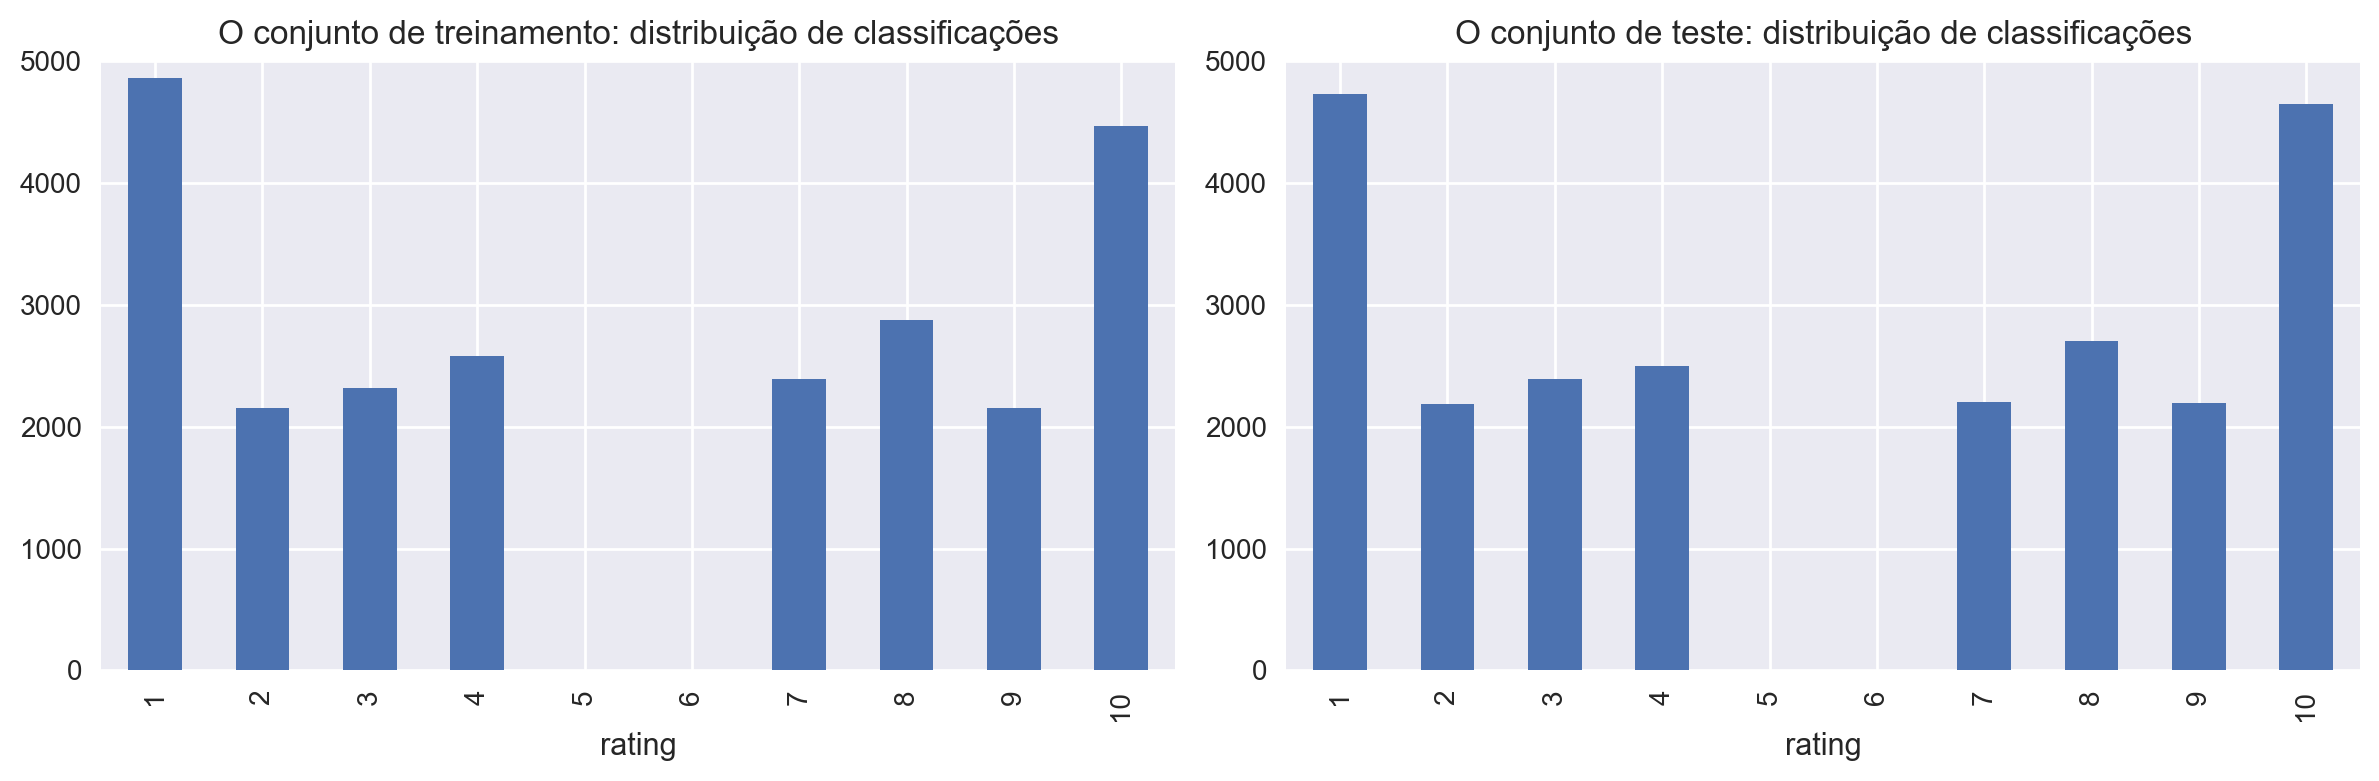

In [98]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/var/folders/jx/_q0hlhjj65zcpy3pb78x177w0000gq/T/ipykernel_57154/1483671763.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/var/folders/jx/_q0hlhjj65zcpy3pb78x177w0000gq/T/ipykernel_57154/1483671763.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
/var/folders/jx/_q0hlhjj65zcpy3pb78x177w0000gq/T/ipykernel_57154/1483671763.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/var/folders/jx/_q0hlhjj65zcpy3pb78x177w0000gq/T/ip

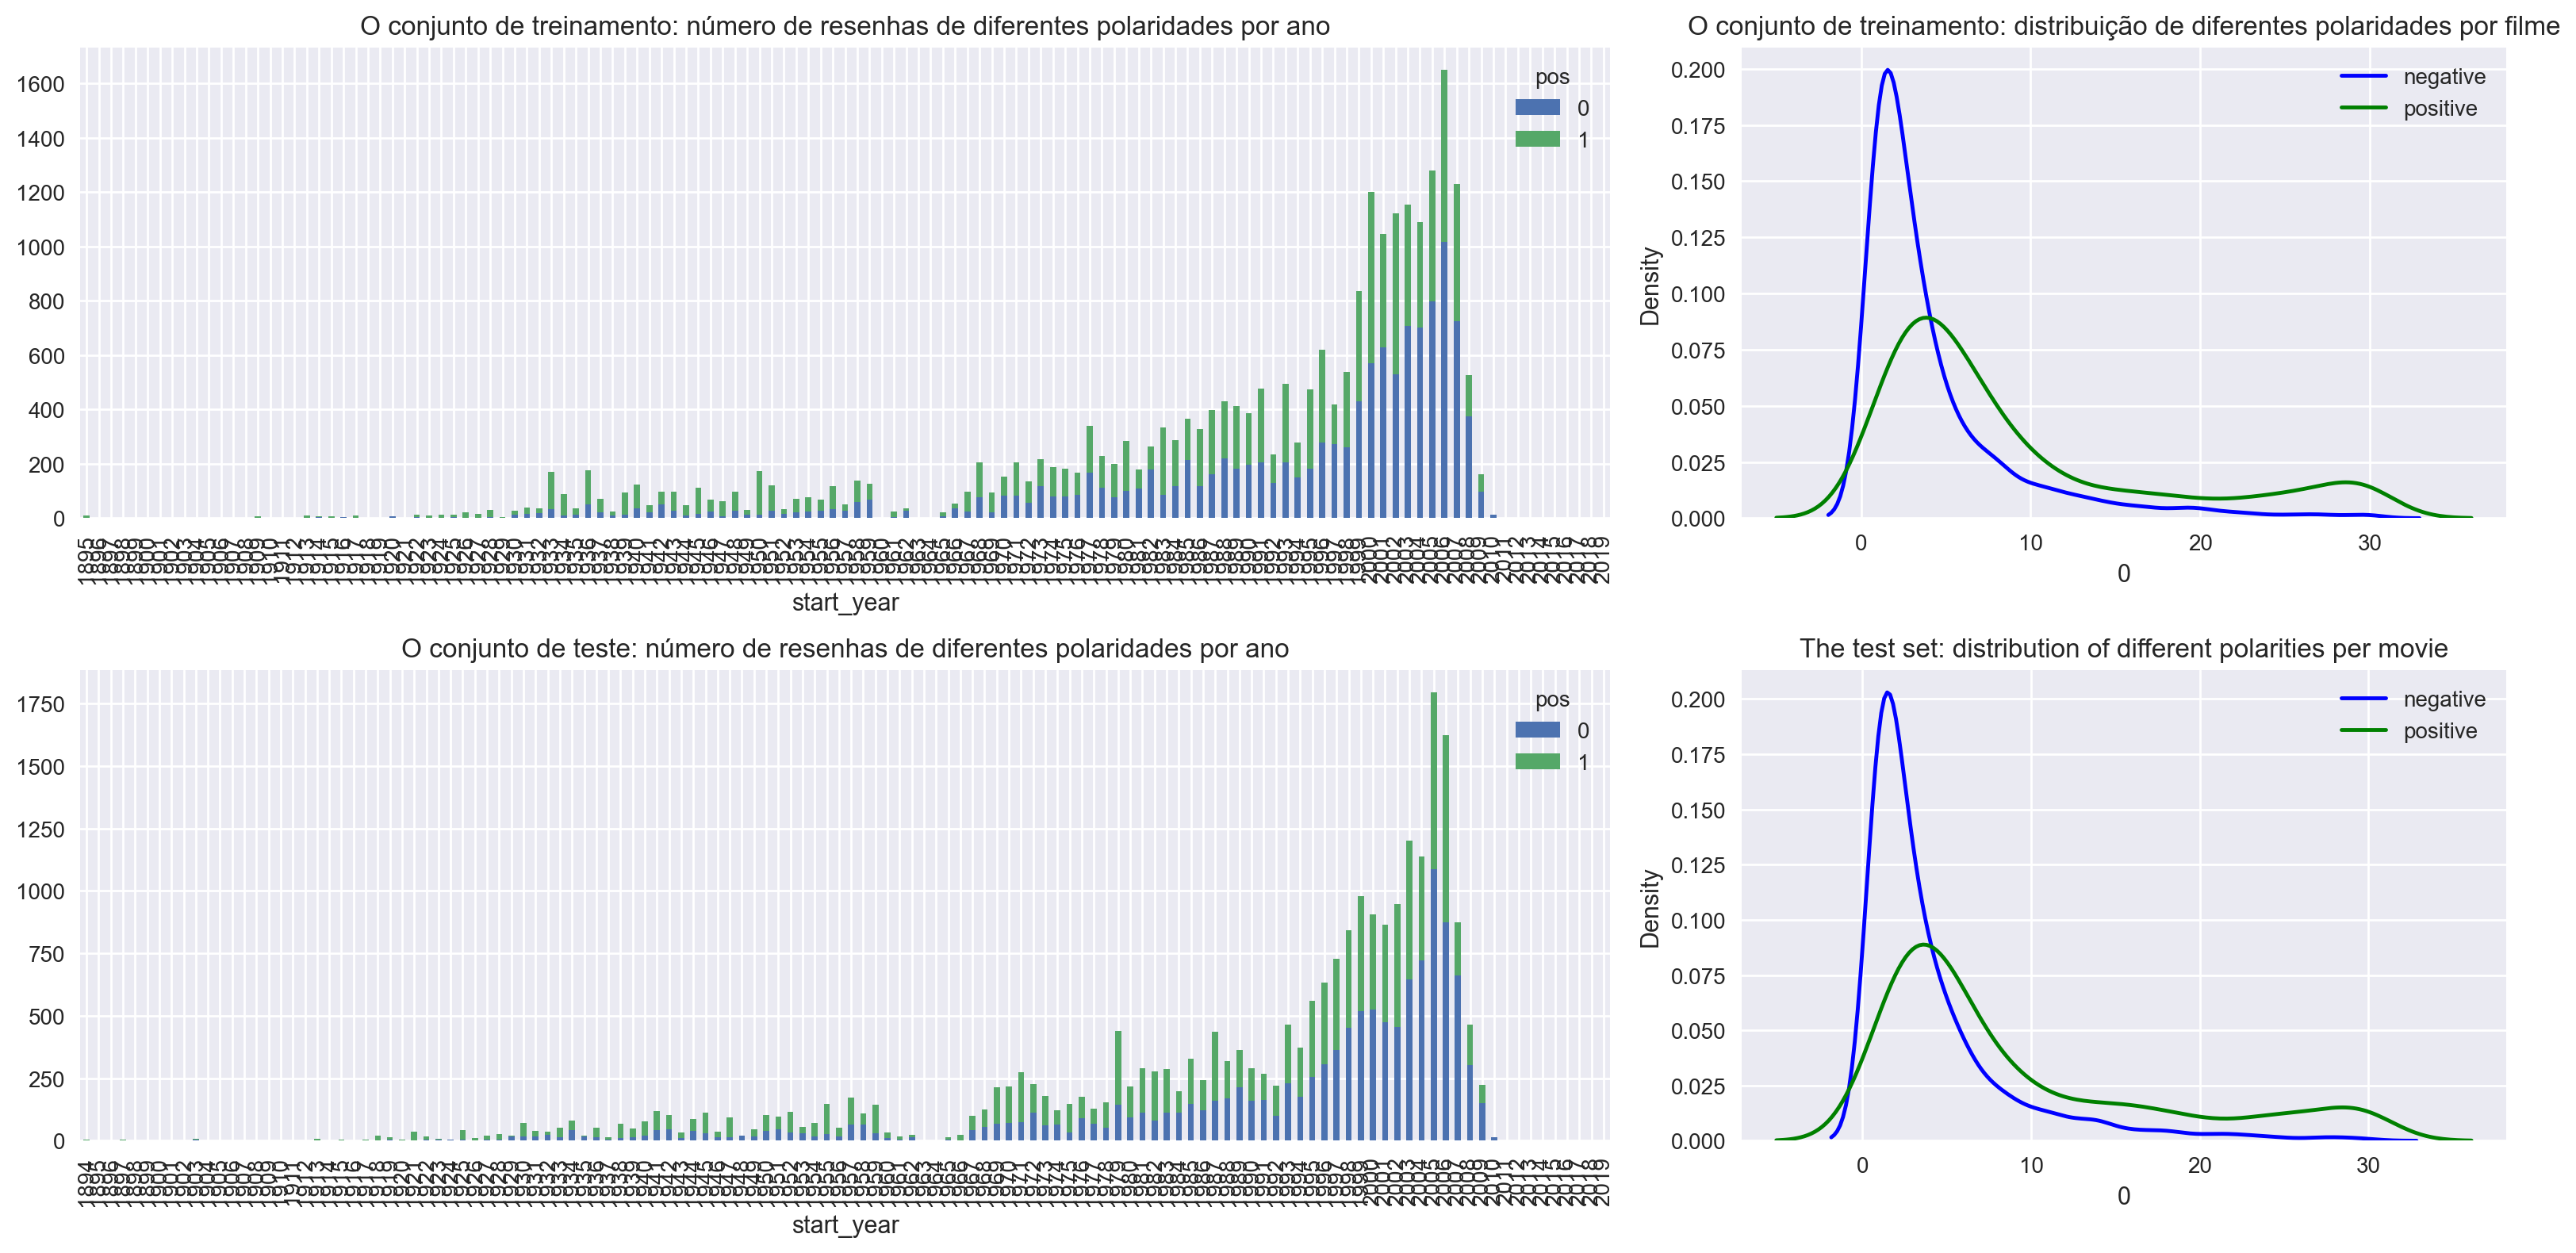

In [99]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [100]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        eval_stats[type]['F1'] = f1_scores[max_f1_score_idx]
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

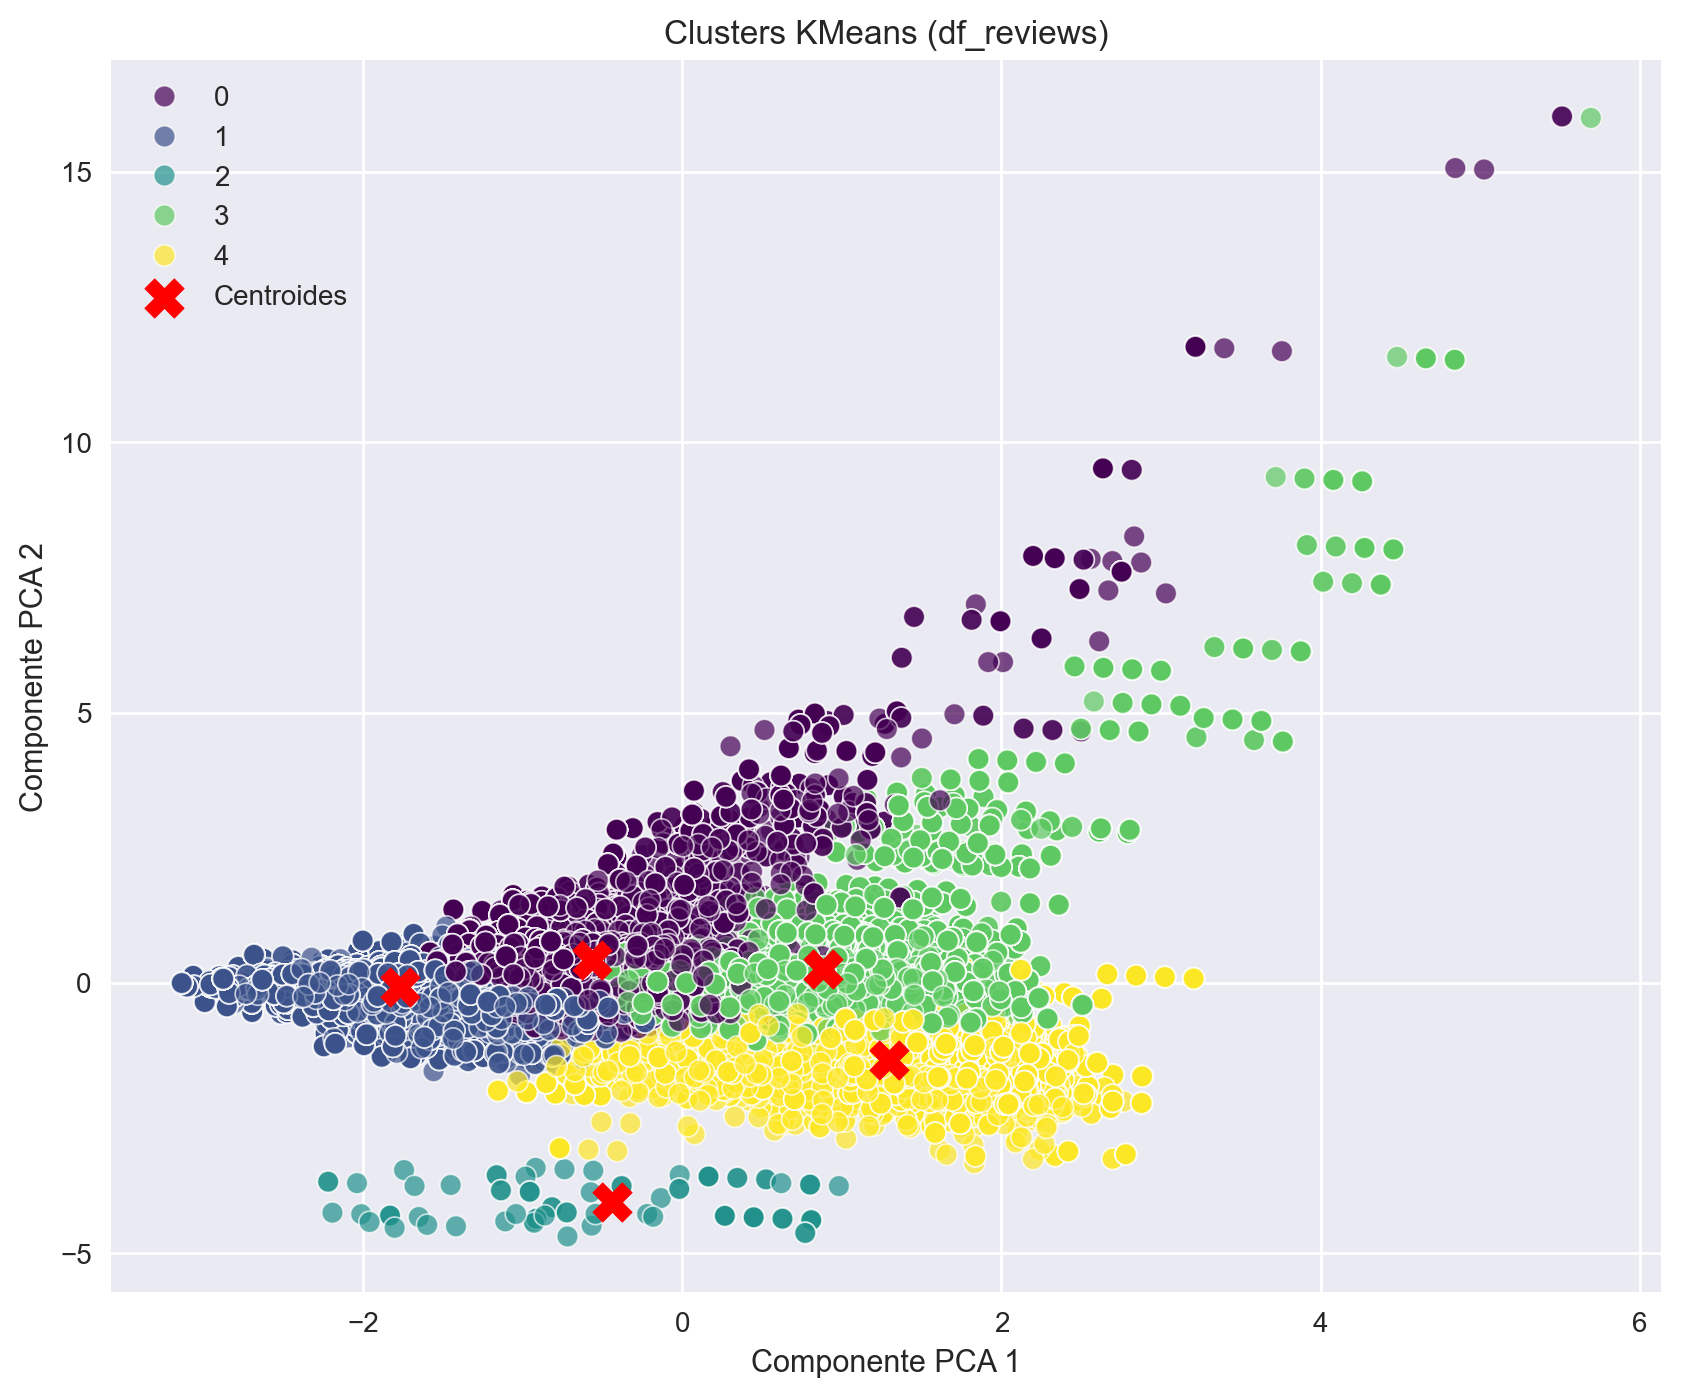

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ======================================================
# 1️⃣ Selecionar apenas colunas numéricas
# ======================================================

numeric_features = df_reviews.select_dtypes(include=['int64', 'float64', 'Int64']).copy()

# Remover colunas que não fazem sentido para clusterização
numeric_features = numeric_features.drop(columns=['pos', 'idx'], errors='ignore')

# Remover linhas com valores nulos
numeric_features = numeric_features.dropna()

# ======================================================
# 2️⃣ Escalonamento
# ======================================================

scaler = StandardScaler()
features_scaled = scaler.fit_transform(numeric_features)

# ======================================================
# 3️⃣ Aplicar KMeans
# ======================================================

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(features_scaled)

clusters = kmeans.labels_

# ======================================================
# 4️⃣ PCA para visualização em 2D
# ======================================================

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(features_scaled)

df_plot = pd.DataFrame({
    'pca1': pca_components[:, 0],
    'pca2': pca_components[:, 1],
    'cluster': clusters
})

# ======================================================
# 5️⃣ Plot
# ======================================================

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    data=df_plot,
    palette='viridis',
    s=60,
    alpha=0.7
)

# Plotar centróides
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroides'
)

plt.title('Clusters KMeans (df_reviews)')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.legend()
plt.show()

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [102]:
# Função de normalização

tqdm.pandas()

def normalize_text(text):
    """
    Normalização básica:
    - converte para string e minúsculas
    - remove tags HTML
    - remove URLs
    - remove pontuação (mantendo letras acentuadas)
    - remove dígitos
    - colapsa espaços múltiplos
    """
    if pd.isna(text):
        return ''
    text = str(text).lower()
    # remove HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # remove urls
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # remove pontuação (mantendo letras acentuadas por usar UNICODE)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    # remove dígitos
    text = re.sub(r'\d+', ' ', text)
    # normaliza espaços
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [103]:
# Aplicar ao conjunto principal (já carregado como df_reviews)
df_reviews['review_norm'] = df_reviews['review'].progress_apply(normalize_text)

# Verificar algumas linhas
print(df_reviews[['review', 'review_norm']].head(3).to_string(index=False))


  0%|          | 0/47331 [00:00<?, ?it/s]

## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [104]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com modelos

### Modelo 0 - Constante

In [105]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report


Treinando DummyClassifier (baseline)
          train  test
Accuracy   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50

Confusion matrix - Dummy
[[11803     0]
 [11732     0]]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     11803
           1       0.00      0.00      0.00     11732

    accuracy                           0.50     23535
   macro avg       0.25      0.50      0.33     23535
weighted avg       0.25      0.50      0.34     23535



/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

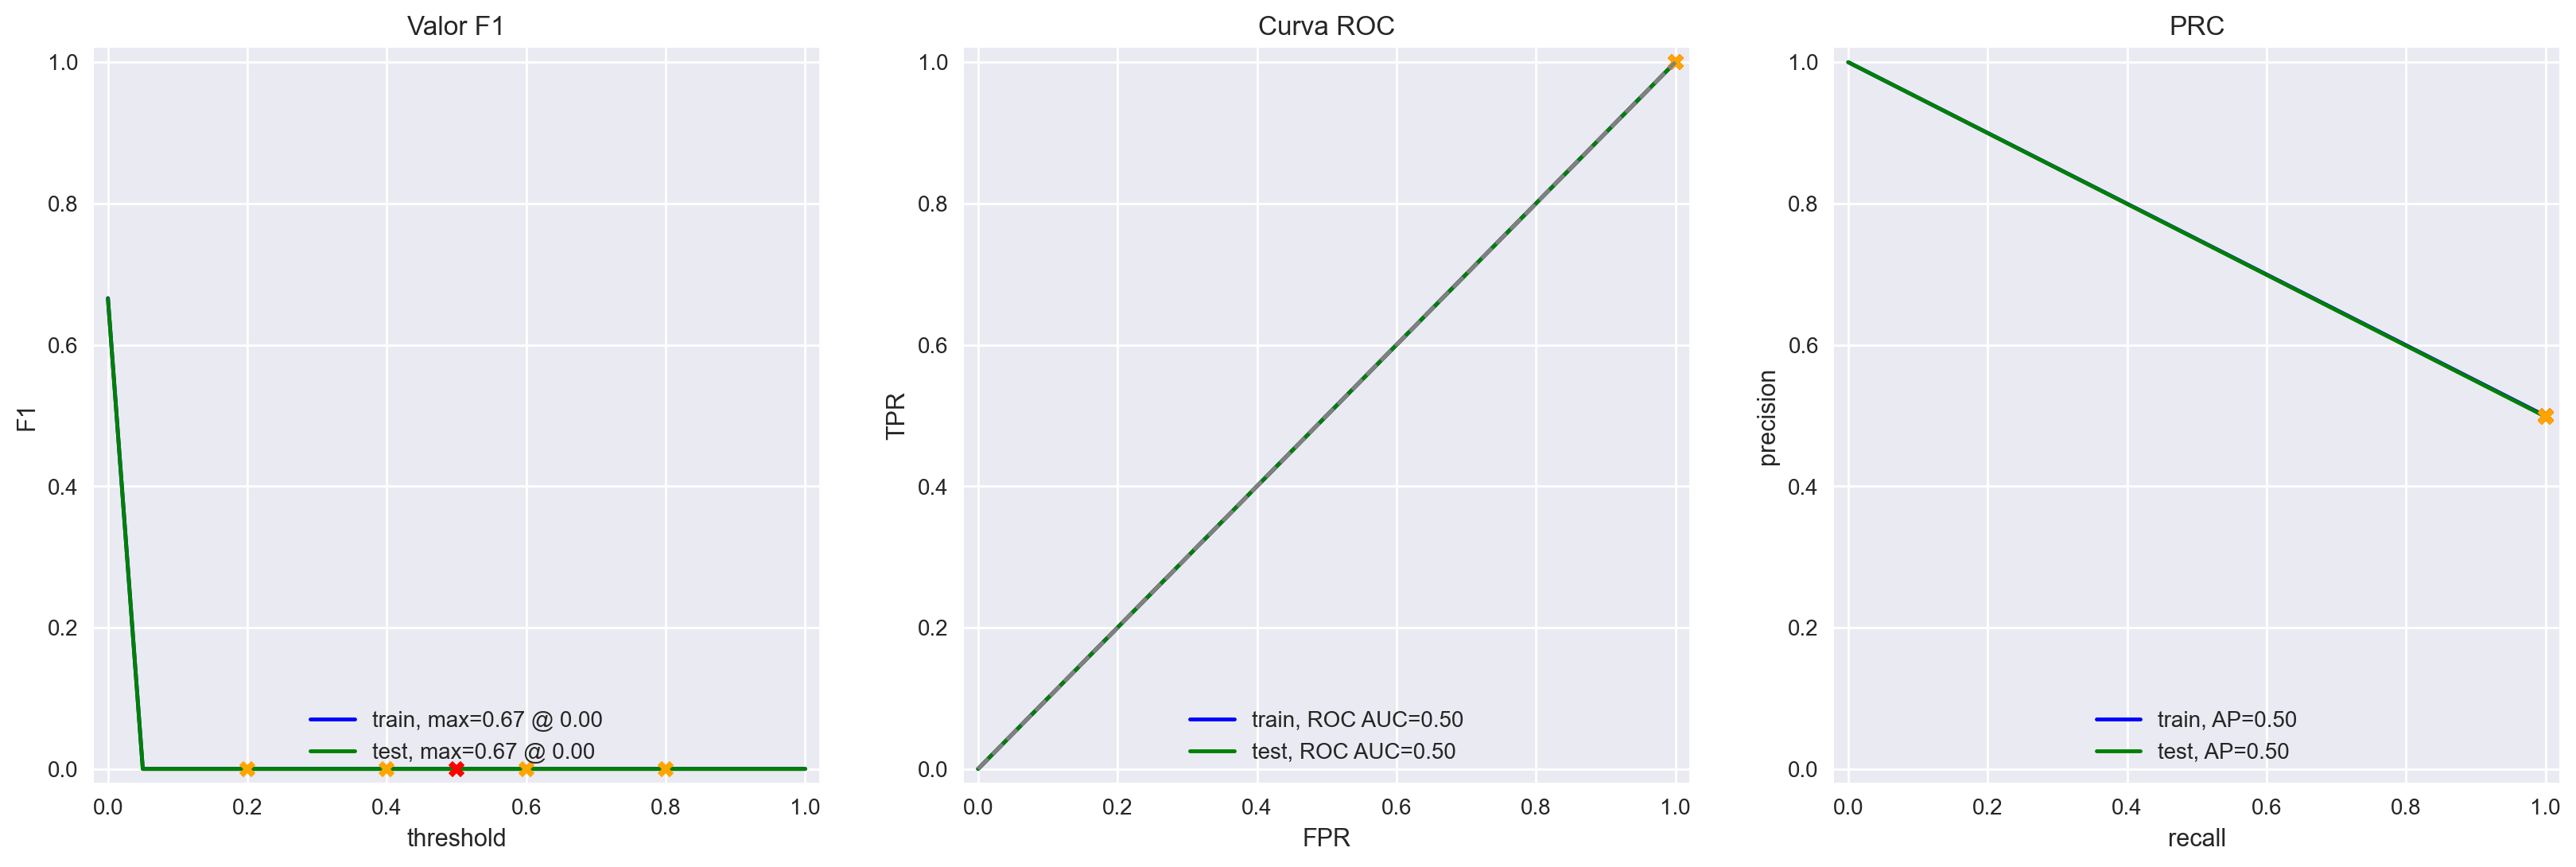

In [106]:
print('Treinando DummyClassifier (baseline)')

model_0 = DummyClassifier(strategy='most_frequent')
model_0.fit(df_reviews_train['review_norm'].values.reshape(-1,1), train_target)
# Dummy aceita qualquer X; usamos reshape para compatibilidade

# Para evaluation precisamos fornecer features no mesmo formato para a função:
# aqui vamos criar features simples (bag-of-length) só para compatibilidade com evaluate_model
# Mas idealmente evaluate_model espera predict_proba: DummyClassifier tem predict_proba
train_features_0 = df_reviews_train['review_norm'].values.reshape(-1,1)
test_features_0 = df_reviews_test['review_norm'].values.reshape(-1,1)

evaluate_model(model_0, train_features_0, train_target, test_features_0, test_target)

pred_0 = model_0.predict(test_features_0)
print()
print('Confusion matrix - Dummy')
print(confusion_matrix(test_target, pred_0))
print(classification_report(test_target, pred_0))

### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF

In [107]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /Users/Pedro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

          train  test
Accuracy   0.92  0.88
F1         0.92  0.89
APS        0.97  0.95
ROC AUC    0.97  0.95
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     11803
           1       0.88      0.89      0.88     11732

    accuracy                           0.88     23535
   macro avg       0.88      0.88      0.88     23535
weighted avg       0.88      0.88      0.88     23535



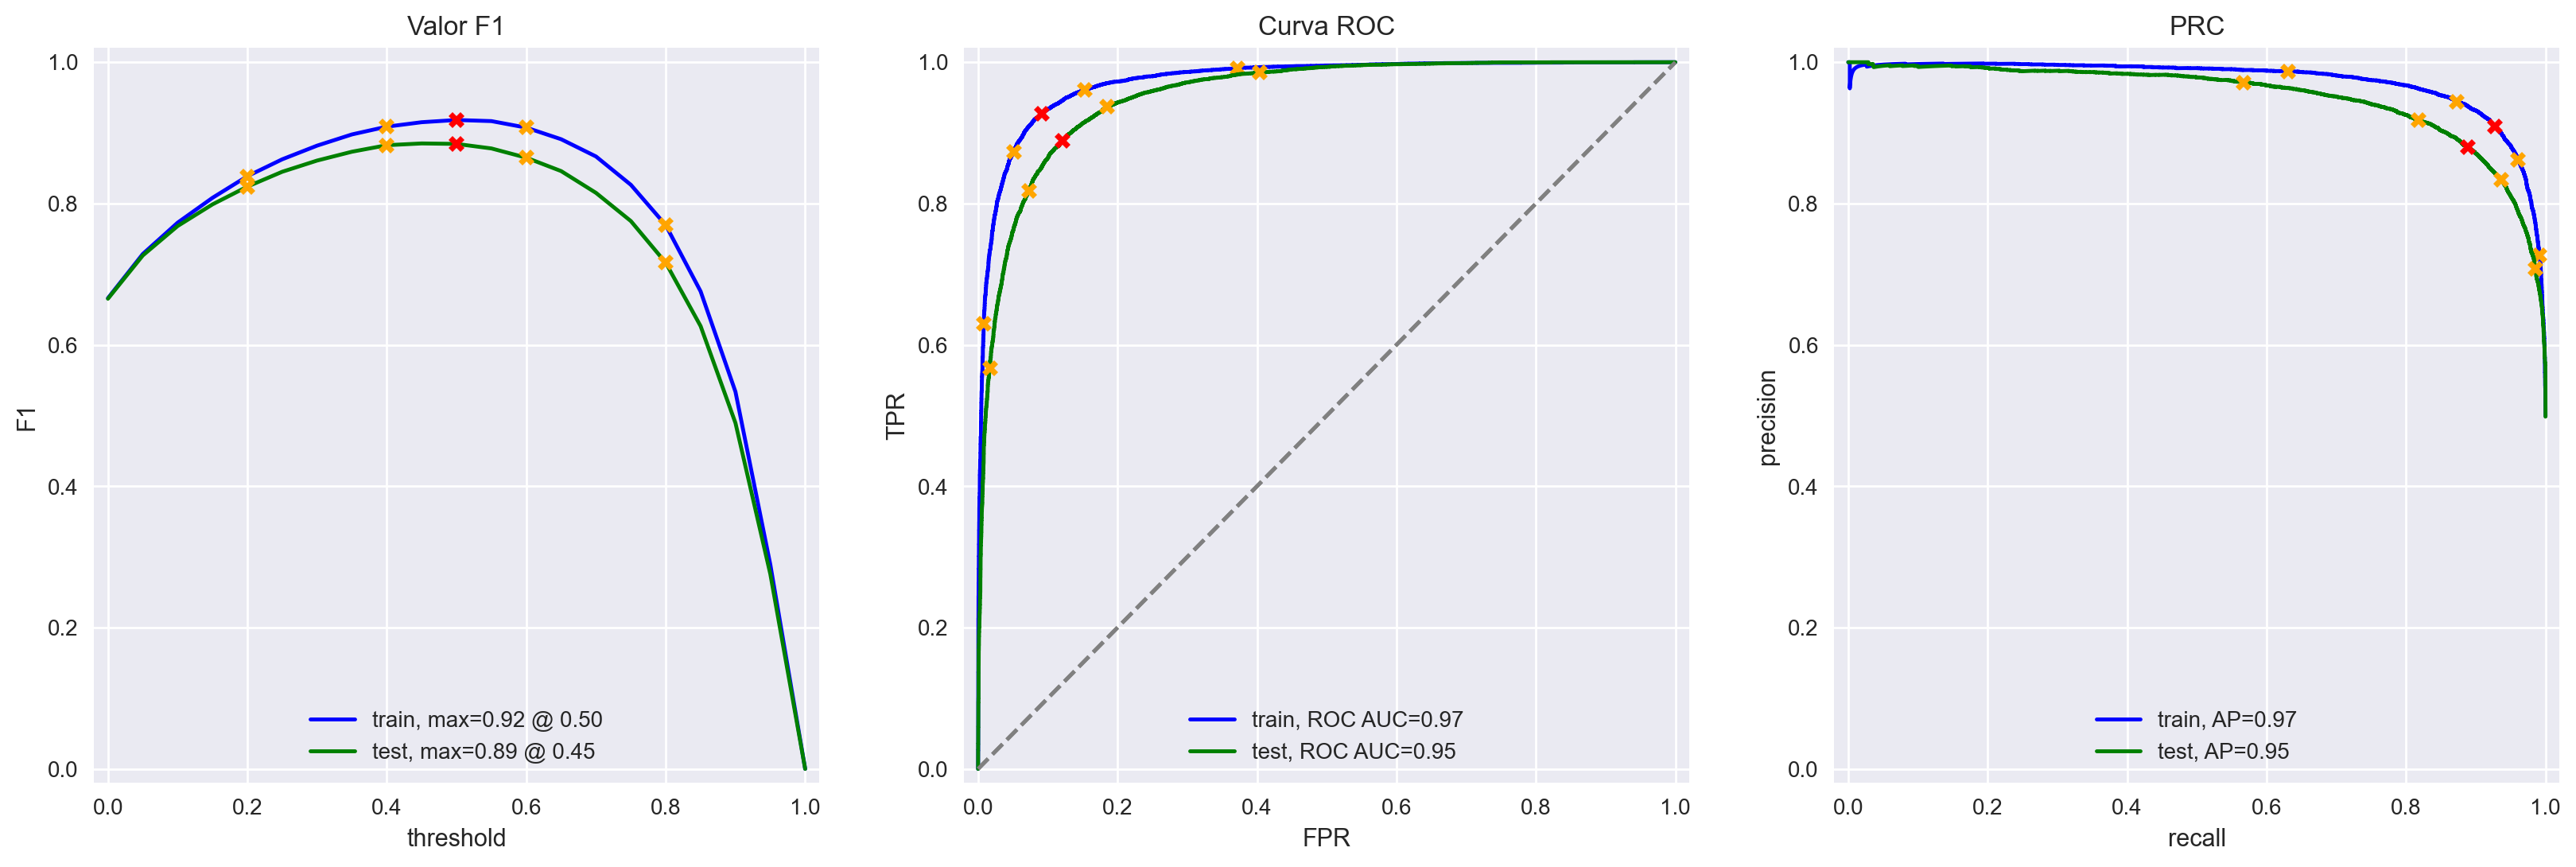

In [108]:
import nltk
nltk.download('stopwords')

stop_eng = stopwords.words('english')

def nltk_preprocess(text):
    # tokenização simples e remoção de stopwords; mantém lemas se quiser adicionar WordNetLemmatizer
    tokens = [w for w in text.split() if w not in stop_eng]
    return " ".join(tokens)

# criar versões pré-processadas
df_reviews_train['review_nltk'] = df_reviews_train['review_norm'].progress_apply(nltk_preprocess)
df_reviews_test['review_nltk']  = df_reviews_test['review_norm'].progress_apply(nltk_preprocess)

tfidf_vectorizer_1 = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), min_df=3, max_df=0.9)
train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_nltk'])
test_features_1  = tfidf_vectorizer_1.transform(df_reviews_test['review_nltk'])

model_1 = LogisticRegression(max_iter=1000)
model_1.fit(train_features_1, train_target)

evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)
print(classification_report(test_target, model_1.predict(test_features_1)))

### Modelo 3 - spaCy, TF-IDF e Regressão Linear

Iniciando pré-processamento rápido com spaCy...
Finalizado!
          train  test
Accuracy   0.91  0.89
F1         0.91  0.89
APS        0.97  0.95
ROC AUC    0.97  0.96
              precision    recall  f1-score   support

           0       0.89      0.88      0.89     11803
           1       0.88      0.90      0.89     11732

    accuracy                           0.89     23535
   macro avg       0.89      0.89      0.89     23535
weighted avg       0.89      0.89      0.89     23535



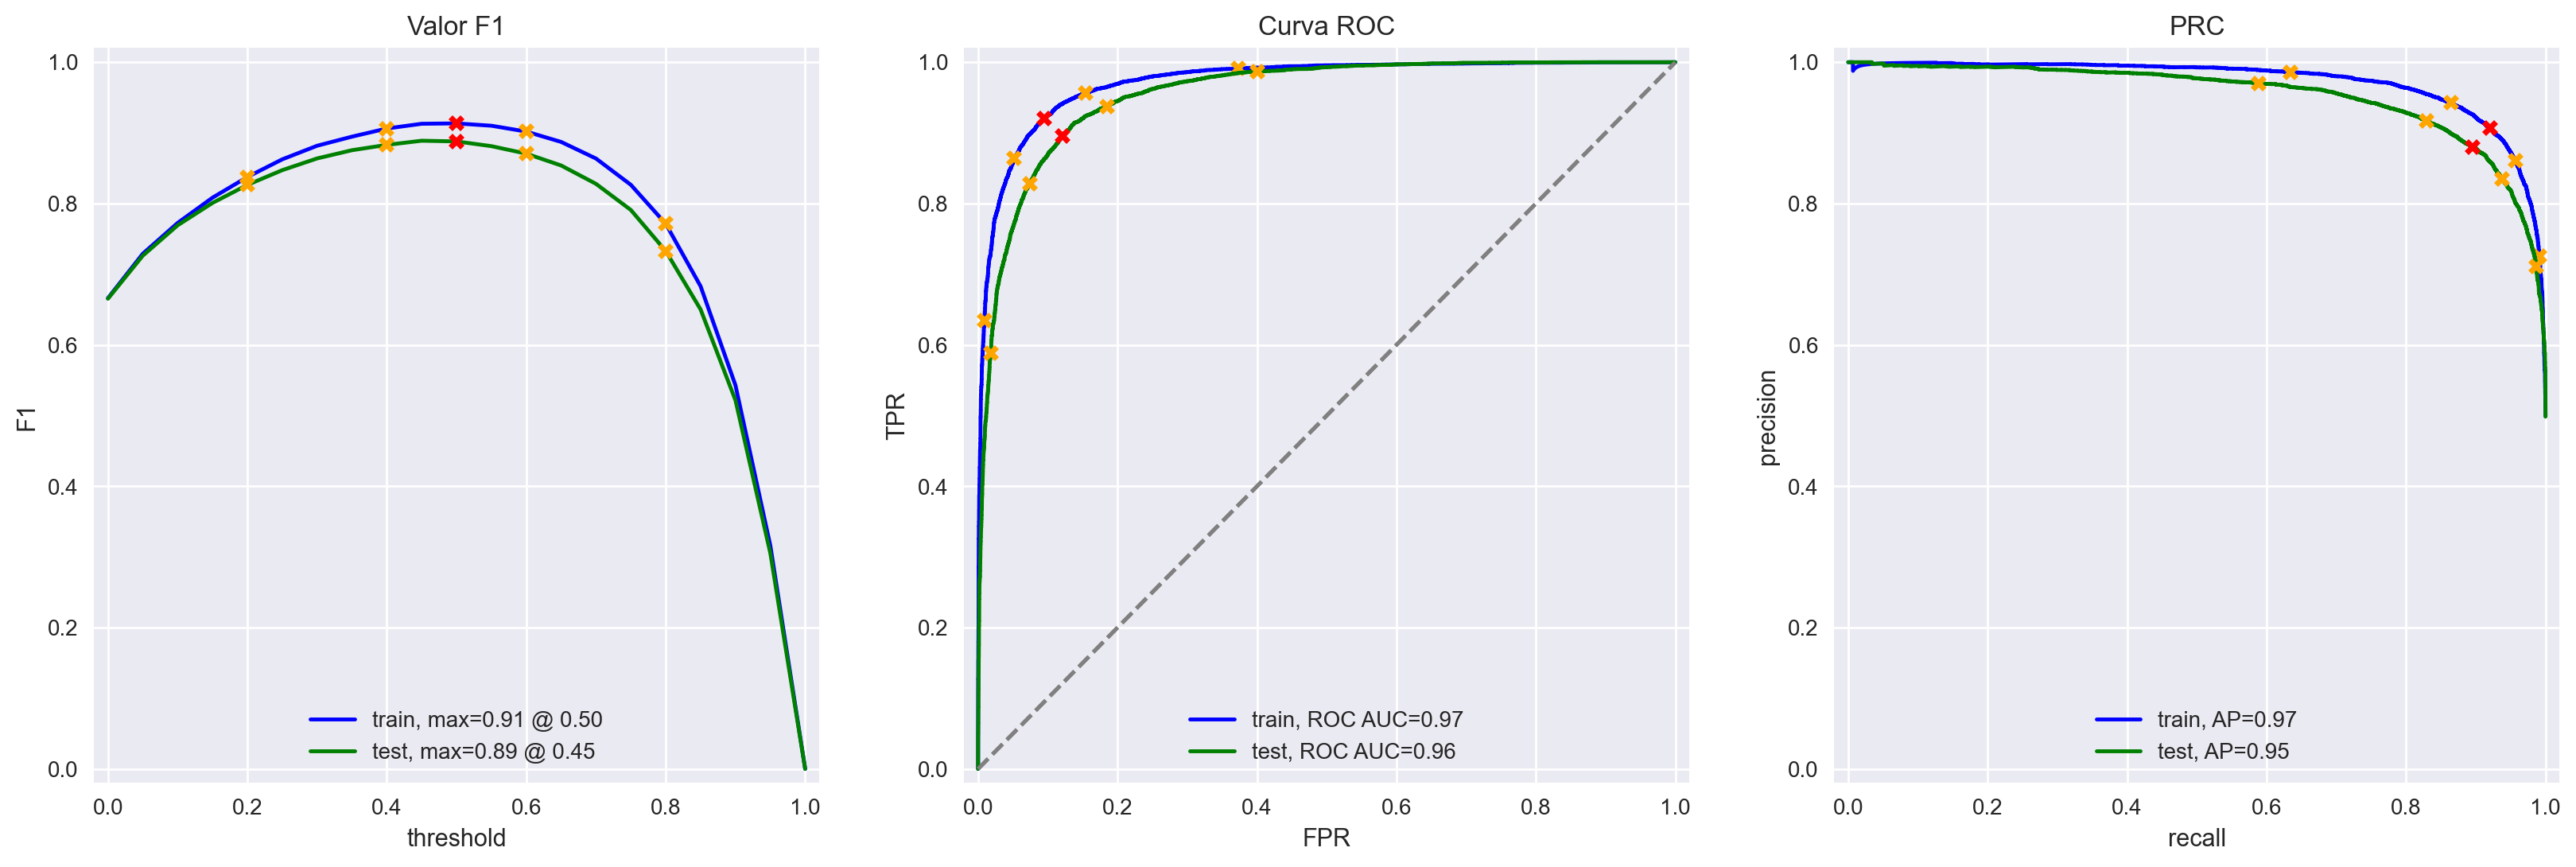

In [110]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Carregar o modelo (certifique-se de já ter baixado o en_core_web_sm)
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# 2. Função Turbo
def fast_preprocessing(texts):
    processed_texts = []
    # n_process=-1 usa o poder total do seu Mac (M1/M2/M3)
    for doc in nlp.pipe(texts, n_process=-1, batch_size=500):
        tokens = [token.lemma_ for token in doc]
        processed_texts.append(' '.join(tokens))
    return processed_texts

# 3. Execução do Pré-processamento
print("Iniciando pré-processamento rápido com spaCy...")
df_reviews_train['review_spacy'] = fast_preprocessing(df_reviews_train['review_norm'])
df_reviews_test['review_spacy'] = fast_preprocessing(df_reviews_test['review_norm'])
print("Finalizado!")

# 4. Vetorização (TF-IDF)
tfidf_vectorizer_3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), min_df=3, max_df=0.9)
train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_spacy'])
test_features_3 = tfidf_vectorizer_3.transform(df_reviews_test['review_spacy'])

# 5. Treinamento
model_3 = LogisticRegression(max_iter=1000)
model_3.fit(train_features_3, train_target)

# 6. Avaliação (Seu procedimento de avaliação)
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)
print(classification_report(test_target, model_3.predict(test_features_3)))

### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.121454 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 733849
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 5000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


          train  test
Accuracy   0.97  0.88
F1         0.97  0.88
APS        1.00  0.95
ROC AUC    1.00  0.95
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     11803
           1       0.87      0.89      0.88     11732

    accuracy                           0.88     23535
   macro avg       0.88      0.88      0.88     23535
weighted avg       0.88      0.88      0.88     23535



/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


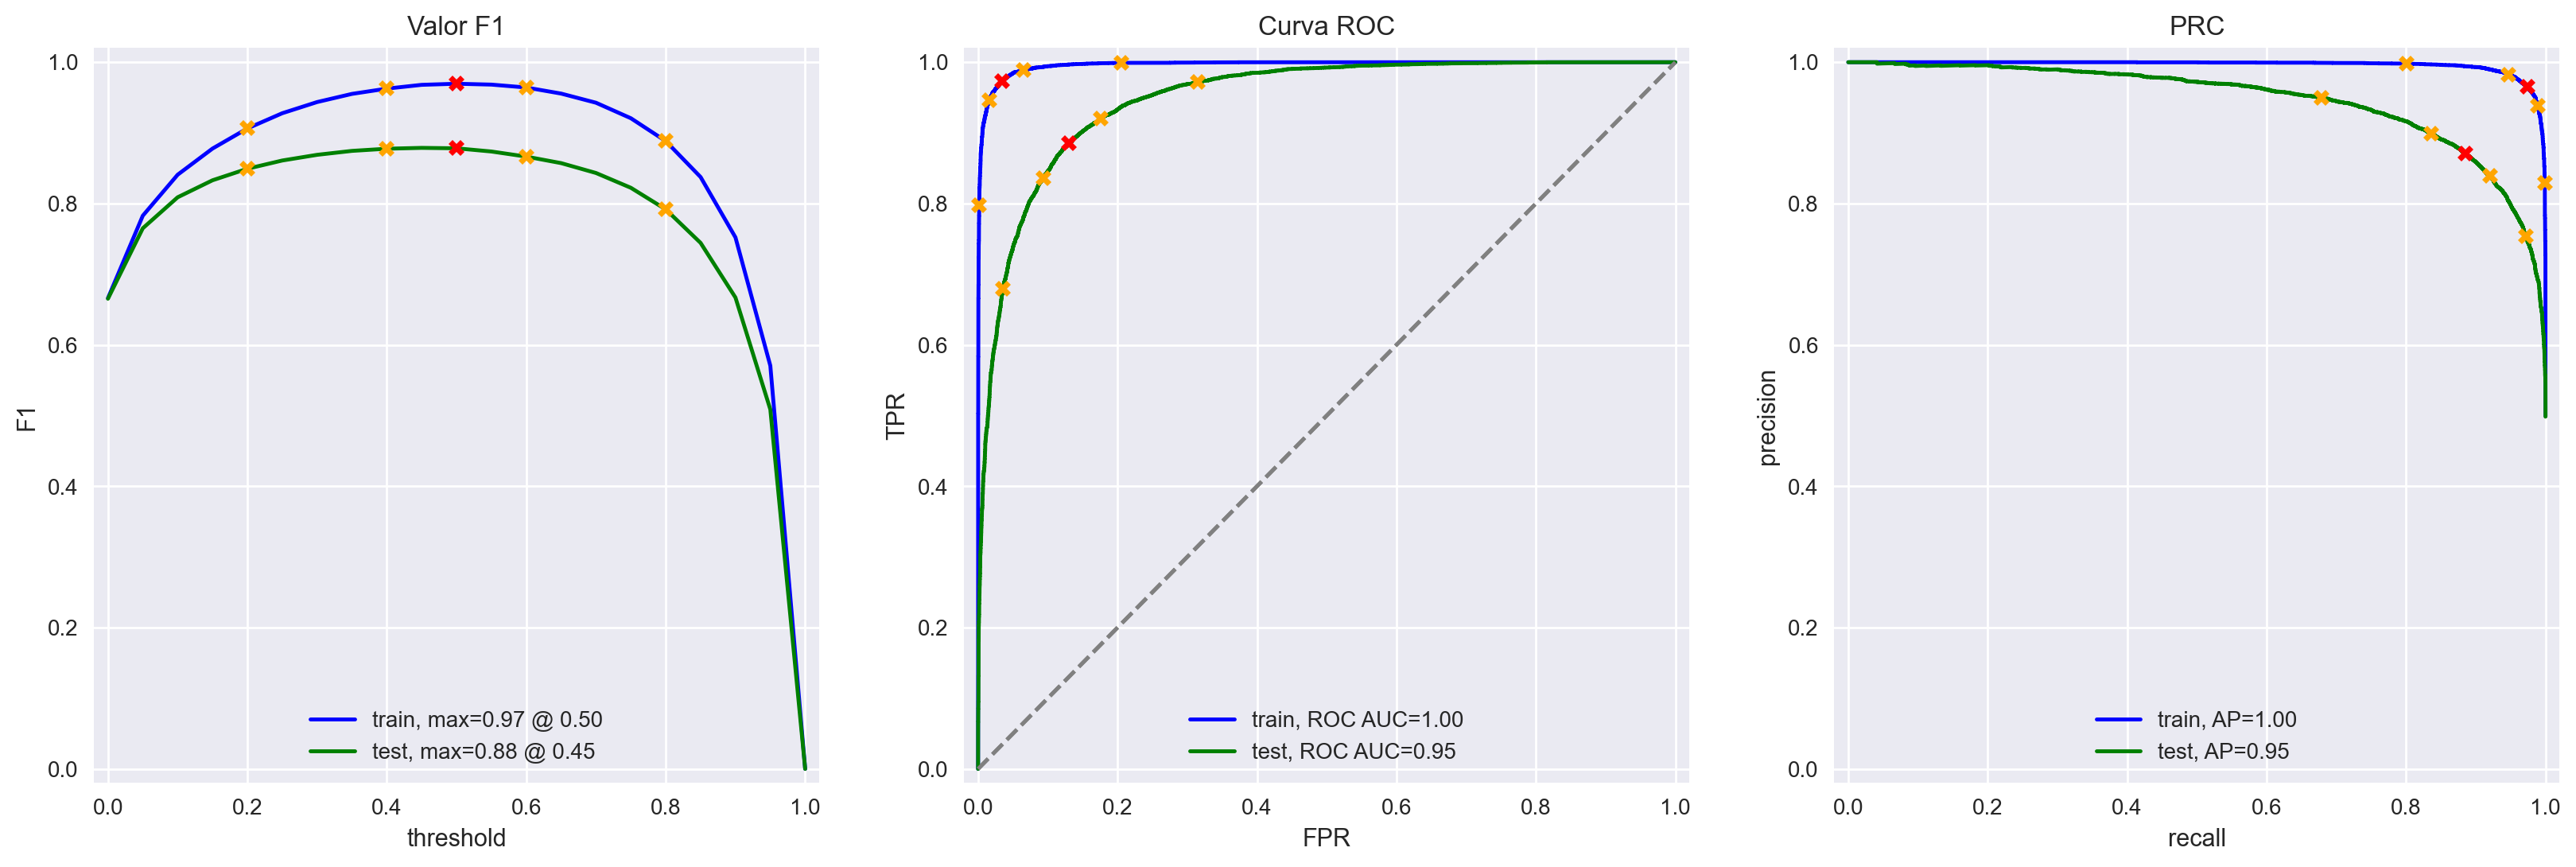

In [112]:
from lightgbm import LGBMClassifier

model_4 = LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
# Reuse train_features_3/test_features_3 (spaCy-processed TF-IDF)
model_4.fit(train_features_3, train_target)

evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)
print(classification_report(test_target, model_4.predict(test_features_3)))


###  Modelo 9 - BERT

In [114]:
import torch
import transformers

In [115]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [116]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # texto para IDs de tokens preenchidos com suas máscaras de atenção
    
    # <coloque seu código aqui para criar ids_list e attention_mask_list>
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
    
    # recebendo incorporações em lotes

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <coloque seu código aqui para criar attention_mask_batch
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

In [119]:
# Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

In [ ]:

# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']


<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>


Caso tenha interesse em como rodar o modelo BERT no google colab (por conta da capacidade computacional), veja um exemplo aqui: [Modelo BERT no Google Colab](https://colab.research.google.com/drive/16BWcgSoSQ-vBuGfPFTURjLgLBYWruua7?usp=sharing).


</div>

## Minhas Resenhas

In [120]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'Eu simplesmente não gostei, não é meu tipo de filme.',
    'Bem, eu fiquei entediado e dormi no meio do filme.',
    'Eu fiquei realmente fascinado com o filme',    
    'Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do filme. Que roubo de dinheiro sem vergonha.',
    'Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original',
    'O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar indo assistir novamente.',
    'Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhenta, nem crianças não vão gostar disso!',
    'Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após episódio, deste emocionante e inteligente novo drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].progress_apply(normalize_text) # <coloque aqui a mesma lógica de normalização do conjunto de dados principal>

# Pré-processar com spaCy (mesma lógica do Modelo 3/4)
my_reviews['review_spacy'] = my_reviews['review_norm'].progress_apply(text_preprocessing_3)

# Transformar com TF-IDF do Modelo 3/4
my_reviews_features = tfidf_vectorizer_3.transform(my_reviews['review_spacy'])

# Fazer previsão de probabilidade com o Modelo 4
my_reviews_pred_prob = model_4.predict_proba(my_reviews_features)[:, 1]  # coluna 1 = probabilidade de positivo

# Exibir resultados
for i, review in enumerate(my_reviews['review'].str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}: {review}')


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

0.71: Eu simplesmente não gostei, não é meu tipo de filme.
0.44: Bem, eu fiquei entediado e dormi no meio do filme.
0.71: Eu fiquei realmente fascinado com o filme
0.68: Os atores pareciam muito velhos e desinteressados, e mesmo assim foram pagos para participar do film
0.56: Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o materia
0.71: O filme tem seus prós e contras, mas eu sinto que em geral é um filme decente. Eu posso me imaginar 
0.72: Que tentativa podre de comédia. Nem uma única piada cai, todo mundo age de forma irritante e barulhe
0.71: Lançar na Netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após


/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Modelo 1

In [121]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidf_vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.44:  eu simplesmente não gostei não é meu tipo de filme
0.50:  bem eu fiquei entediado e dormi no meio do filme
0.76:  eu fiquei realmente fascinado com o filme
0.44:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.29:  eu não esperava que a nova versão fosse tão boa os escritores realmente se importaram com o material
0.56:  o filme tem seus prós e contras mas eu sinto que em geral é um filme decente eu posso me imaginar in
0.53:  que tentativa podre de comédia nem uma única piada cai todo mundo age de forma irritante e barulhent
0.53:  lançar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após


### Modelo 3

In [122]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.44:  eu simplesmente não gostei não é meu tipo de filme
0.02:  bem eu fiquei entediado e dormi no meio do filme
0.48:  eu fiquei realmente fascinado com o filme
0.37:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.10:  eu não esperava que a nova versão fosse tão boa os escritores realmente se importaram com o material
0.48:  o filme tem seus prós e contras mas eu sinto que em geral é um filme decente eu posso me imaginar in
0.53:  que tentativa podre de comédia nem uma única piada cai todo mundo age de forma irritante e barulhent
0.56:  lançar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após


### Modelo 4

In [123]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.71:  eu simplesmente não gostei não é meu tipo de filme
0.44:  bem eu fiquei entediado e dormi no meio do filme
0.71:  eu fiquei realmente fascinado com o filme
0.68:  os atores pareciam muito velhos e desinteressados e mesmo assim foram pagos para participar do filme
0.56:  eu não esperava que a nova versão fosse tão boa os escritores realmente se importaram com o material
0.71:  o filme tem seus prós e contras mas eu sinto que em geral é um filme decente eu posso me imaginar in
0.72:  que tentativa podre de comédia nem uma única piada cai todo mundo age de forma irritante e barulhent
0.71:  lançar na netflix foi uma jogada corajosa e eu realmente aprecio ser capaz de assistir episódio após


/Users/Pedro/Documents/film-junky-sentiment-analysis/film_junky_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Modelo 9

In [124]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

ValueError: need at least one array to concatenate

## Conclusões

# 📌 Conclusões

Neste estudo, exploramos diferentes abordagens para classificação binária de textos, avaliando desde modelos mais complexos até alternativas mais leves. A seguir, sintetizamos os principais resultados e aprendizados do processo.

---

## 🔍 Resultados Obtidos

O **LGBMClassifier** treinado sobre representações **TF-IDF processadas com spaCy** apresentou:

- **Acurácia de 0.88** no conjunto de teste  
- **F1-score de 0.88**, equilibrado entre as classes  
- **ROC AUC de 0.95**, indicando boa separação entre as classes  
- Resultados consistentes entre treino (**0.97 F1**) e teste (**0.88 F1**), mostrando leve overfitting, mas dentro do esperado para dados textuais  

---

## ⚙️ Vantagens do Modelo Final

- Modelo simples, rápido e fácil de treinar  
- Baixa complexidade computacional  
- Generalização sólida mesmo sem técnicas avançadas  
- Evita dependência de embeddings grandes ou modelos de linguagem pré-treinados  

---

## 🧠 Principais Insights

- Representações tradicionais como **TF-IDF** continuam altamente eficazes em tarefas de classificação quando combinadas com modelos baseados em árvores de decisão.
- A diferença entre desempenho de treino e teste é natural para dados textuais extensos e pode ser mitigada com:
  - Regularização adicional  
  - Redução de dimensionalidade  
  - Tunagem mais profunda de hiperparâmetros  
- Modelos mais avançados (transformers, embeddings densos) podem melhorar a performance marginalmente, mas nem sempre justificam o custo computacional adicional.

---

## 🚀 Próximos Passos Possíveis

- Testar versões otimizadas de TF-IDF (n-grams, `min_df`, `max_df`)  
- Experimentar redução de dimensionalidade com **SVD (LSA)**  
- Avaliar modelos híbridos:
  - TF-IDF + Logistic Regression  
  - LightGBM + embeddings (fastText, sentence-transformers)  
- Validar o modelo em dados reais de produção  
- Monitorar possível drift linguístico ao longo do tempo  

---

## ✅ Conclusão Geral

O modelo baseado em **LightGBM + TF-IDF** mostrou-se uma solução equilibrada, eficiente e de excelente custo-benefício. Ele entrega alta performance com baixo custo computacional e serve como um baseline forte para futuras evoluções mais complexas.

<div class="alert alert-block alert-warning">

<b>Comentário: </b> <a class="tocSkip"></a>


Era recomendado adicionar conclusão com suas observações

</div>